In [1]:
# Import libraries
import pandas as pd
import numpy as np
import torch
import re
import warnings
from transformers import AutoTokenizer, AutoModelForMaskedLM
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load dataset
df = pd.read_csv(
    r"C:\Users\kehin\thesis project\data\MIMICIII_Cleaned_Merged.csv",
    on_bad_lines='skip',
    engine='python',
    encoding='utf-8'
)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Consolidate ethnicity and filter
ethnicity_map = {
    'WHITE': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'BLACK/AFRICAN AMERICAN': 'Black',
    'BLACK/AFRICAN': 'Black',
    'HISPANIC OR LATINO': 'Hispanic',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic',
    'HISPANIC/LATINO - COLOMBIAN': 'Hispanic',
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - VIETNAMESE': 'Asian'
}

df['RACE_GROUP'] = df['ETHNICITY'].map(ethnicity_map)
df['GENDER_GROUP'] = df['GENDER'].map({'M': 'Male', 'F': 'Female'})
df_filtered = df[df['RACE_GROUP'].notna()].copy()

print("Filtered shape:", df_filtered.shape)
print("\nRace distribution:")
print(df_filtered['RACE_GROUP'].value_counts())

Shape: (1176, 21)
Columns: ['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'CHARTDATE', 'CHARTTIME', 'STORETIME', 'CATEGORY', 'DESCRIPTION', 'CGID', 'ISERROR', 'TEXT', 'word_non_compliant', 'word_resistant', 'word_agitated', 'word_uncooperative', 'any_bias_word', 'ETHNICITY', 'GENDER', 'DOB', 'DOD', 'EXPIRE_FLAG']
Filtered shape: (1065, 23)

Race distribution:
RACE_GROUP
White       890
Black       130
Hispanic     24
Asian        21
Name: count, dtype: int64


In [3]:
# Check word frequency in actual clinical notes
all_text = " ".join(df_filtered['TEXT'].dropna().values).lower()

candidate_words = [
    # Evaluative framing candidates
    "cooperative", "uncooperative", "compliance", "noncompliance",
    "compliant", "noncompliant", "refuses", "refused", "refusing",
    "rejects", "rejected", "agreeable", "disagreeable",
    # Behavioral language candidates
    "resistant", "difficult", "agitated", "combative", "hostile",
    "pleasant", "calm", "anxious", "confused", "oriented",
    "willing", "reliable", "adherent", "engaged", "stable",
    "appropriate", "inappropriate", "cooperative", "uncooperative"
]

print("Word frequency in clinical notes:\n")
freq_results = []
for word in set(candidate_words):
    count = len(re.findall(r'\b' + word + r'\b', all_text))
    freq_results.append({"word": word, "count": count})

freq_df = pd.DataFrame(freq_results).sort_values("count", ascending=False)
print(freq_df.to_string(index=False))

Word frequency in clinical notes:

         word  count
       stable   2310
     oriented    524
  appropriate    288
    difficult    249
     confused    155
      refused    140
     pleasant    116
    resistant     97
     agitated     77
   compliance     74
  cooperative     52
      anxious     51
    compliant     34
     refusing     28
noncompliance     16
    combative     12
inappropriate     12
 noncompliant     11
      engaged     11
      refuses      9
     adherent      9
         calm      8
      willing      7
    agreeable      4
     reliable      3
uncooperative      2
     rejected      1
      rejects      0
      hostile      0
 disagreeable      0


In [4]:
# Load ClinicalBERT and check tokens
from transformers import AutoTokenizer, AutoModelForMaskedLM

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
print(f"Loading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)
model.eval()
print("ClinicalBERT loaded\n")

# Check tokens
final_candidates = [
    "compliant", "cooperative", "compliance",
    "refused", "refusing", "noncompliant", "noncompliance",
    "pleasant", "oriented", "appropriate", "calm",
    "difficult", "resistant", "agitated", "combative",
    "confused", "inappropriate"
]

print("Token check:\n")
for word in final_candidates:
    tokens = tokenizer.encode(word, add_special_tokens=False)
    status = "OK" if len(tokens) == 1 else f"DROPPED - {len(tokens)} tokens: {tokenizer.convert_ids_to_tokens(tokens)}"
    print(f"{word}: {status}")

Loading emilyalsentzer/Bio_ClinicalBERT...
ClinicalBERT loaded

Token check:

compliant: DROPPED - 2 tokens: ['com', '##pliant']
cooperative: OK
compliance: OK
refused: OK
refusing: OK
noncompliant: DROPPED - 3 tokens: ['non', '##com', '##pliant']
noncompliance: DROPPED - 4 tokens: ['non', '##com', '##p', '##liance']
pleasant: OK
oriented: OK
appropriate: OK
calm: OK
difficult: OK
resistant: OK
agitated: OK
combative: DROPPED - 2 tokens: ['combat', '##ive']
confused: OK
inappropriate: OK


In [5]:
# define word list
evaluative_positive = ["cooperative", "compliance"]
evaluative_negative = ["refused", "refusing"]
behavioral_positive = ["pleasant", "oriented", "appropriate", "calm"]
behavioral_negative = ["difficult", "resistant", "agitated", "confused", "inappropriate"]

evaluative_words = evaluative_positive + evaluative_negative
behavioral_words = behavioral_positive + behavioral_negative
target_words = evaluative_words + behavioral_words

print("Evaluative Framing — Positive:", evaluative_positive)
print("Evaluative Framing — Negative:", evaluative_negative)
print("Behavioral Language — Positive:", behavioral_positive)
print("Behavioral Language — Negative:", behavioral_negative)
print("\nTotal target words:", len(target_words))

Evaluative Framing — Positive: ['cooperative', 'compliance']
Evaluative Framing — Negative: ['refused', 'refusing']
Behavioral Language — Positive: ['pleasant', 'oriented', 'appropriate', 'calm']
Behavioral Language — Negative: ['difficult', 'resistant', 'agitated', 'confused', 'inappropriate']

Total target words: 13


In [6]:
# extract real clinical sentence templates
def extract_clinical_templates(df, target_words, max_per_word=20):
    templates = []
    for word in target_words:
        matching_notes = df[
            df['TEXT'].str.contains(r'\b' + word + r'\b',
                                   case=False, na=False, regex=True)
        ]['TEXT'].values

        count = 0
        for note in matching_notes:
            if count >= max_per_word:
                break
            sentences = re.split(r'\n|(?<=[.!?])\s+', str(note))
            for sent in sentences:
                sent = sent.strip()
                if not re.search(r'\b' + word + r'\b', sent, re.IGNORECASE):
                    continue
                if len(sent.split()) < 5 or len(sent.split()) > 30:
                    continue
                if '[**' in sent:
                    continue
                templates.append({
                    "word": word,
                    "original_sentence": sent,
                    "category": "Evaluative Framing" if word in evaluative_words else "Behavioral Language",
                    "valence": "Positive" if word in (evaluative_positive + behavioral_positive) else "Negative"
                })
                count += 1

    return pd.DataFrame(templates)

templates_df = extract_clinical_templates(df_filtered, target_words)
print(f"Total clinical templates extracted: {len(templates_df)}")
print("\nTemplates per word:")
print(templates_df['word'].value_counts())
print("\nSample templates:")
print(templates_df[['word', 'original_sentence']].head(10).to_string(index=False))

Total clinical templates extracted: 238

Templates per word:
word
cooperative      21
oriented         21
difficult        21
compliance       20
refused          20
pleasant         20
appropriate      20
resistant        20
agitated         20
confused         20
refusing         18
inappropriate    11
calm              6
Name: count, dtype: int64

Sample templates:
       word                                                original_sentence
cooperative                         Presently A+Ox3- cooperative and lovely.
cooperative         Gen: awake, calm, cooperative and pleasant, lying in bed
cooperative              Alert, cooperative white male in no acute distress.
cooperative                          patient not cooperative during the exam
cooperative                     Gen: Alert, NAD, cooperative, well appearing
cooperative     Neurologic examination:  Awake, alert and cooperative, could
cooperative patient was diaphoretic and tremulous, oriented x 3, cooperative
cooperative  

In [7]:
# define LPBA function
def get_log_probability(sentence, target_word, tokenizer, model):
    target_tokens = tokenizer.encode(target_word, add_special_tokens=False)
    if len(target_tokens) != 1:
        return None
    target_id = target_tokens[0]

    masked_sentence = re.sub(
        r'\b' + re.escape(target_word) + r'\b',
        tokenizer.mask_token,
        sentence,
        flags=re.IGNORECASE
    )

    if tokenizer.mask_token not in masked_sentence:
        return None

    inputs = tokenizer(
        masked_sentence,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    mask_pos = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
    if len(mask_pos) == 0:
        return None

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    log_probs = torch.log_softmax(logits[0, mask_pos[0], :], dim=-1)
    return log_probs[target_id].item()

print("LPBA function defined")
race_descriptors = {
    "White": "white",
    "Black": "black",
    "Hispanic": "hispanic",
    "Asian": "asian"
}

gender_descriptors = {
    "Male": "male",
    "Female": "female"
}

def insert_demographic_descriptor(sentence, race_desc, gender_desc):
    if re.search(r'\bpatient\b', sentence, re.IGNORECASE):
        return re.sub(
            r'\bpatient\b',
            f"{race_desc} {gender_desc} patient",
            sentence,
            count=1,
            flags=re.IGNORECASE
        )
    else:
        return f"The {race_desc} {gender_desc} patient: {sentence}"

print("Demographic insertion function defined")

LPBA function defined
Demographic insertion function defined


In [8]:
# run full LPBA analysis
results = []
print("Running LPBA analysis on real clinical sentences...\n")

for _, template_row in templates_df.iterrows():
    word = template_row['word']
    original_sentence = template_row['original_sentence']
    category = template_row['category']
    valence = template_row['valence']

    for race_label, race_desc in race_descriptors.items():
        for gender_label, gender_desc in gender_descriptors.items():
            modified_sentence = insert_demographic_descriptor(
                original_sentence, race_desc, gender_desc
            )
            log_prob = get_log_probability(
                modified_sentence, word, tokenizer, model
            )
            if log_prob is not None:
                results.append({
                    "Race": race_label,
                    "Gender": gender_label,
                    "Original_Sentence": original_sentence,
                    "Modified_Sentence": modified_sentence,
                    "Target_Word": word,
                    "Category": category,
                    "Valence": valence,
                    "Log_Probability": log_prob
                })

results_df = pd.DataFrame(results)
print(f"Analysis complete. Total observations: {len(results_df)}")
print("\nObservations per race group:")
print(results_df['Race'].value_counts())
print("\nObservations per word:")
print(results_df['Target_Word'].value_counts())

Running LPBA analysis on real clinical sentences...

Analysis complete. Total observations: 1904

Observations per race group:
Race
White       476
Black       476
Hispanic    476
Asian       476
Name: count, dtype: int64

Observations per word:
Target_Word
cooperative      168
oriented         168
difficult        168
compliance       160
refused          160
pleasant         160
appropriate      160
resistant        160
agitated         160
confused         160
refusing         144
inappropriate     88
calm              48
Name: count, dtype: int64


In [12]:
# print result
results_df.to_csv(
    r"C:\Users\kehin\thesis project\data\LPBA_revised_results.csv",
    index=False
)
print("Results saved to LPBA_revised_results.csv")

Results saved to LPBA_revised_results.csv


In [11]:
# summary statistics
print("Mean Log Probabilities by Race and Category\n")
summary = results_df.groupby(
    ["Race", "Category", "Valence"]
)["Log_Probability"].mean().reset_index()
print(summary.to_string(index=False))

print("\nMean Log Probability per Target Word by Race\n")
word_summary = results_df.groupby(
    ["Target_Word", "Race"]
)["Log_Probability"].mean().unstack()
print(word_summary.to_string())

Mean Log Probabilities by Race and Category

    Race            Category  Valence  Log_Probability
   Asian Behavioral Language Negative        -3.130347
   Asian Behavioral Language Positive        -3.267983
   Asian  Evaluative Framing Negative        -3.771538
   Asian  Evaluative Framing Positive        -2.567393
   Black Behavioral Language Negative        -3.131272
   Black Behavioral Language Positive        -3.381629
   Black  Evaluative Framing Negative        -3.733966
   Black  Evaluative Framing Positive        -2.791330
Hispanic Behavioral Language Negative        -3.116662
Hispanic Behavioral Language Positive        -3.240770
Hispanic  Evaluative Framing Negative        -3.843042
Hispanic  Evaluative Framing Positive        -2.677190
   White Behavioral Language Negative        -3.141215
   White Behavioral Language Positive        -3.342926
   White  Evaluative Framing Negative        -3.733402
   White  Evaluative Framing Positive        -2.625152

Mean Log Probabilit

In [14]:
# statistical test
print(" One-Way ANOVA: Race Group Differences\n")

for category in ["Evaluative Framing", "Behavioral Language"]:
    for valence in ["Positive", "Negative"]:
        groups = []
        for race in ["White", "Black", "Hispanic", "Asian"]:
            group_data = results_df[
                (results_df["Category"] == category) &
                (results_df["Valence"] == valence) &
                (results_df["Race"] == race)
            ]["Log_Probability"].values
            if len(group_data) > 0:
                groups.append(group_data)

        if len(groups) >= 2:
            f_stat, p_value = stats.f_oneway(*groups)
            significance = "SIGNIFICANT" if p_value < 0.05 else "not significant"
            print(f"{category} | {valence}")
            print(f"F={f_stat:.4f} | p={p_value:.4f} | {significance}\n")

print("\nPairwise T-Tests: Each Group vs White (Reference)\n")
minority_groups = ["Black", "Hispanic", "Asian"]

for category in ["Evaluative Framing", "Behavioral Language"]:
    for valence in ["Positive", "Negative"]:
        print(f" {category} | {valence}")
        white_data = results_df[
            (results_df["Category"] == category) &
            (results_df["Valence"] == valence) &
            (results_df["Race"] == "White")
        ]["Log_Probability"].values

        for minority in minority_groups:
            minority_data = results_df[
                (results_df["Category"] == category) &
                (results_df["Valence"] == valence) &
                (results_df["Race"] == minority)
            ]["Log_Probability"].values

            if len(minority_data) > 0:
                t_stat, p_value = stats.ttest_ind(white_data, minority_data)
                direction = "higher" if minority_data.mean() > white_data.mean() else "lower"
                significance = "SIGNIFICANT" if p_value < 0.05 else "not significant"
                print(f"White vs {minority}: t={t_stat:.4f}, p={p_value:.4f} | "
                      f"{minority} {direction} prob than White | {significance}")
        print()

 One-Way ANOVA: Race Group Differences

Evaluative Framing | Positive
F=0.1276 | p=0.9437 | not significant

Evaluative Framing | Negative
F=0.0451 | p=0.9873 | not significant

Behavioral Language | Positive
F=0.0599 | p=0.9808 | not significant

Behavioral Language | Negative
F=0.0020 | p=0.9999 | not significant


Pairwise T-Tests: Each Group vs White (Reference)

 Evaluative Framing | Positive
White vs Black: t=0.4416, p=0.6594 | Black lower prob than White | not significant
White vs Hispanic: t=0.1366, p=0.8915 | Hispanic lower prob than White | not significant
White vs Asian: t=-0.1550, p=0.8770 | Asian higher prob than White | not significant

 Evaluative Framing | Negative
White vs Black: t=0.0017, p=0.9987 | Black lower prob than White | not significant
White vs Hispanic: t=0.3150, p=0.7532 | Hispanic lower prob than White | not significant
White vs Asian: t=0.1106, p=0.9121 | Asian lower prob than White | not significant

 Behavioral Language | Positive
White vs Black: t=0.10

In [16]:
# Check what ClinicalBERT actually predicts at MASK position
# for a sample sentence across demographic groups

sample_sentence = templates_df[templates_df['word'] == 'difficult']['original_sentence'].iloc[0]
print("Original sentence:", sample_sentence)
print()

for race_label, race_desc in race_descriptors.items():
    modified = insert_demographic_descriptor(sample_sentence, race_desc, "male")
    masked = re.sub(r'\bdifficult\b', tokenizer.mask_token, modified, flags=re.IGNORECASE)
    
    inputs = tokenizer(masked, return_tensors="pt", truncation=True, max_length=512)
    mask_pos = (inputs["input_ids"] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    log_probs = torch.log_softmax(logits[0, mask_pos[0], :], dim=-1)
    top_tokens = torch.topk(log_probs, 10)
    
    print(f"{race_label}")
    for score, idx in zip(top_tokens.values, top_tokens.indices):
        print(f"  {tokenizer.convert_ids_to_tokens([idx.item()])[0]}: {score.item():.4f}")
    print()

Original sentence: difficult to assess due to CPAP machine.

White
  unable: -0.2629
  difficult: -1.9189
  Unable: -2.6053
  hard: -5.7532
  able: -6.0845
  inability: -7.7277
  failed: -8.6386
  Hard: -8.7892
  impossible: -8.8038
  easy: -8.8169

Black
  unable: -0.2491
  difficult: -2.0549
  Unable: -2.4993
  hard: -5.8686
  able: -6.1277
  inability: -7.6634
  failed: -8.4270
  impossible: -8.7262
  easy: -8.7393
  Hard: -8.7642

Hispanic
  unable: -0.3535
  difficult: -1.5236
  Unable: -2.7276
  hard: -5.3650
  able: -5.6816
  inability: -6.9887
  failed: -8.3069
  easy: -8.5641
  Hard: -8.6114
  impossible: -8.6941

Asian
  unable: -0.3510
  difficult: -1.5907
  Unable: -2.5890
  hard: -5.3475
  able: -5.7261
  inability: -6.8396
  failed: -8.1359
  not: -8.2978
  Hard: -8.4013
  easy: -8.4233



In [17]:
# Filter for sentences where target word describes the patient
patient_describing_templates = templates_df[
    templates_df['original_sentence'].str.contains(
        r'\bpatient\b|\bhe\b|\bshe\b|\bpt\b', 
        case=False, 
        regex=True
    )
].copy()

print(f"Patient-describing templates: {len(patient_describing_templates)}")
print("\nTemplates per word:")
print(patient_describing_templates['word'].value_counts())
print("\nSample sentences:")
print(patient_describing_templates[['word','original_sentence']].head(20).to_string(index=False))

Patient-describing templates: 65

Templates per word:
word
refused          16
refusing         11
agitated          9
oriented          6
confused          5
cooperative       4
compliance        4
difficult         3
inappropriate     3
appropriate       2
pleasant          1
calm              1
Name: count, dtype: int64

Sample sentences:
       word                                                original_sentence
cooperative                          patient not cooperative during the exam
cooperative patient was diaphoretic and tremulous, oriented x 3, cooperative
cooperative    is Alert, cooperative and performs command, he is trached and
cooperative General: patient appears comfortable;  alert, cooperative; he is
 compliance       note, the patient has had poor dietary compliance of late,
 compliance    The patient reports compliance with medications and no recent
 compliance     for non-compliance both when she is oriented and when she is
 compliance    also mentioned that the p

In [18]:
# Drop words with fewer than 3 patient-describing templates
sufficient_words = patient_describing_templates['word'].value_counts()
sufficient_words = sufficient_words[sufficient_words >= 3].index.tolist()
print("Words with sufficient templates:", sufficient_words)

filtered_templates = patient_describing_templates[
    patient_describing_templates['word'].isin(sufficient_words)
].copy()

print(f"\nFinal template count: {len(filtered_templates)}")
print("\nFinal templates per word:")
print(filtered_templates['word'].value_counts())

Words with sufficient templates: ['refused', 'refusing', 'agitated', 'oriented', 'confused', 'cooperative', 'compliance', 'difficult', 'inappropriate']

Final template count: 61

Final templates per word:
word
refused          16
refusing         11
agitated          9
oriented          6
confused          5
cooperative       4
compliance        4
difficult         3
inappropriate     3
Name: count, dtype: int64


In [19]:
# Rerun LPBA on patient-describing templates only
results = []
print("Running revised LPBA on patient-describing sentences...\n")

for _, template_row in filtered_templates.iterrows():
    word = template_row['word']
    original_sentence = template_row['original_sentence']
    category = template_row['category']
    valence = template_row['valence']

    for race_label, race_desc in race_descriptors.items():
        for gender_label, gender_desc in gender_descriptors.items():
            modified_sentence = insert_demographic_descriptor(
                original_sentence, race_desc, gender_desc
            )
            log_prob = get_log_probability(
                modified_sentence, word, tokenizer, model
            )
            if log_prob is not None:
                results.append({
                    "Race": race_label,
                    "Gender": gender_label,
                    "Original_Sentence": original_sentence,
                    "Modified_Sentence": modified_sentence,
                    "Target_Word": word,
                    "Category": category,
                    "Valence": valence,
                    "Log_Probability": log_prob
                })

results_df = pd.DataFrame(results)
print(f"Analysis complete. Total observations: {len(results_df)}")
print("\nObservations per race group:")
print(results_df['Race'].value_counts())
print("\nObservations per word:")
print(results_df['Target_Word'].value_counts())

Running revised LPBA on patient-describing sentences...

Analysis complete. Total observations: 488

Observations per race group:
Race
White       122
Black       122
Hispanic    122
Asian       122
Name: count, dtype: int64

Observations per word:
Target_Word
refused          128
refusing          88
agitated          72
oriented          48
confused          40
cooperative       32
compliance        32
difficult         24
inappropriate     24
Name: count, dtype: int64


In [20]:
# Summary statistics
print("Mean Log Probabilities by Race and Category\n")
summary = results_df.groupby(
    ["Race", "Category", "Valence"]
)["Log_Probability"].mean().reset_index()
print(summary.to_string(index=False))

print("\n Mean Log Probability per Target Word by Race\n")
word_summary = results_df.groupby(
    ["Target_Word", "Race"]
)["Log_Probability"].mean().unstack()
print(word_summary.to_string())

Mean Log Probabilities by Race and Category

    Race            Category  Valence  Log_Probability
   Asian Behavioral Language Negative        -3.161553
   Asian Behavioral Language Positive        -0.109311
   Asian  Evaluative Framing Negative        -3.201865
   Asian  Evaluative Framing Positive        -4.099078
   Black Behavioral Language Negative        -3.348728
   Black Behavioral Language Positive        -0.089620
   Black  Evaluative Framing Negative        -3.222344
   Black  Evaluative Framing Positive        -4.470591
Hispanic Behavioral Language Negative        -3.243177
Hispanic Behavioral Language Positive        -0.110557
Hispanic  Evaluative Framing Negative        -3.254875
Hispanic  Evaluative Framing Positive        -4.284024
   White Behavioral Language Negative        -3.263912
   White Behavioral Language Positive        -0.095796
   White  Evaluative Framing Negative        -3.182405
   White  Evaluative Framing Positive        -4.271542

 Mean Log Probabili

In [23]:
# Paired analysis - compare same sentence across racial groups
print("Paired T-Tests: Same Sentences Across Groups\n")

for word in results_df['Target_Word'].unique():
    word_df = results_df[results_df['Target_Word'] == word].copy()
    
    white_probs = word_df[word_df['Race'] == 'White'].sort_values(
        'Original_Sentence')['Log_Probability'].values
    
    for minority in minority_groups:
        minority_probs = word_df[word_df['Race'] == minority].sort_values(
            'Original_Sentence')['Log_Probability'].values
        
        if len(white_probs) == len(minority_probs):
            t_stat, p_value = stats.ttest_rel(white_probs, minority_probs)
            direction = "higher" if minority_probs.mean() > white_probs.mean() else "lower"
            significance = "SIGNIFICANT" if p_value < 0.05 else "not significant"
            print(f"{word} | White vs {minority}: t={t_stat:.4f}, p={p_value:.4f} | "
                  f"{minority} {direction} prob | {significance}")
    print()

Paired T-Tests: Same Sentences Across Groups

cooperative | White vs Black: t=-0.7450, p=0.4806 | Black higher prob | not significant
cooperative | White vs Hispanic: t=0.4526, p=0.6645 | Hispanic lower prob | not significant
cooperative | White vs Asian: t=-0.5368, p=0.6081 | Asian higher prob | not significant

compliance | White vs Black: t=3.6332, p=0.0084 | Black lower prob | SIGNIFICANT
compliance | White vs Hispanic: t=-0.3022, p=0.7713 | Hispanic higher prob | not significant
compliance | White vs Asian: t=-1.7931, p=0.1160 | Asian higher prob | not significant

refused | White vs Black: t=2.0197, p=0.0521 | Black lower prob | not significant
refused | White vs Hispanic: t=2.6335, p=0.0131 | Hispanic lower prob | SIGNIFICANT
refused | White vs Asian: t=1.3602, p=0.1836 | Asian lower prob | not significant

refusing | White vs Black: t=-1.5863, p=0.1276 | Black higher prob | not significant
refusing | White vs Hispanic: t=0.1353, p=0.8936 | Hispanic lower prob | not significant


In [25]:
# Save significant findings summary
sig_results = []

for word in results_df['Target_Word'].unique():
    word_df = results_df[results_df['Target_Word'] == word].copy()
    white_probs = word_df[word_df['Race'] == 'White'].sort_values(
        'Original_Sentence')['Log_Probability'].values
    
    for minority in minority_groups:
        minority_probs = word_df[word_df['Race'] == minority].sort_values(
            'Original_Sentence')['Log_Probability'].values
        
        if len(white_probs) == len(minority_probs):
            t_stat, p_value = stats.ttest_rel(white_probs, minority_probs)
            direction = "higher" if minority_probs.mean() > white_probs.mean() else "lower"
            sig_results.append({
                "Target_Word": word,
                "Comparison": f"White vs {minority}",
                "Minority_Group": minority,
                "White_Mean": white_probs.mean(),
                "Minority_Mean": minority_probs.mean(),
                "Mean_Difference": minority_probs.mean() - white_probs.mean(),
                "t_statistic": t_stat,
                "p_value": p_value,
                "Direction": direction,
                "Significant": p_value < 0.05,
                "Category": results_df[results_df['Target_Word'] == word]['Category'].iloc[0],
                "Valence": results_df[results_df['Target_Word'] == word]['Valence'].iloc[0]
            })

sig_df = pd.DataFrame(sig_results)
sig_df.to_csv(
    r"C:\Users\kehin\thesis project\data\LPBA_significant_results.csv",
    index=False
)

print("SIGNIFICANT FINDINGS ONLY\n")
significant_only = sig_df[sig_df['Significant'] == True].sort_values('p_value')
print(significant_only[[
    'Target_Word', 'Comparison', 'White_Mean', 
    'Minority_Mean', 'Mean_Difference', 't_statistic', 
    'p_value', 'Category', 'Valence'
]].to_string(index=False))

SIGNIFICANT FINDINGS ONLY

Target_Word        Comparison  White_Mean  Minority_Mean  Mean_Difference  t_statistic  p_value            Category  Valence
   agitated    White vs Black   -2.436537      -2.630777        -0.194240     5.333876 0.000055 Behavioral Language Negative
   confused White vs Hispanic   -2.487685      -2.792021        -0.304336     4.185911 0.002355 Behavioral Language Negative
   agitated White vs Hispanic   -2.436537      -2.282184         0.154353    -3.300693 0.004224 Behavioral Language Negative
   confused    White vs Asian   -2.487685      -2.733179        -0.245494     3.728356 0.004709 Behavioral Language Negative
 compliance    White vs Black   -4.218537      -4.665870        -0.447333     3.633176 0.008362  Evaluative Framing Positive
    refused White vs Hispanic   -2.822410      -2.936924        -0.114514     2.633510 0.013064  Evaluative Framing Negative
   oriented    White vs Asian   -0.095796      -0.109311        -0.013514     2.814492 0.016833 Be

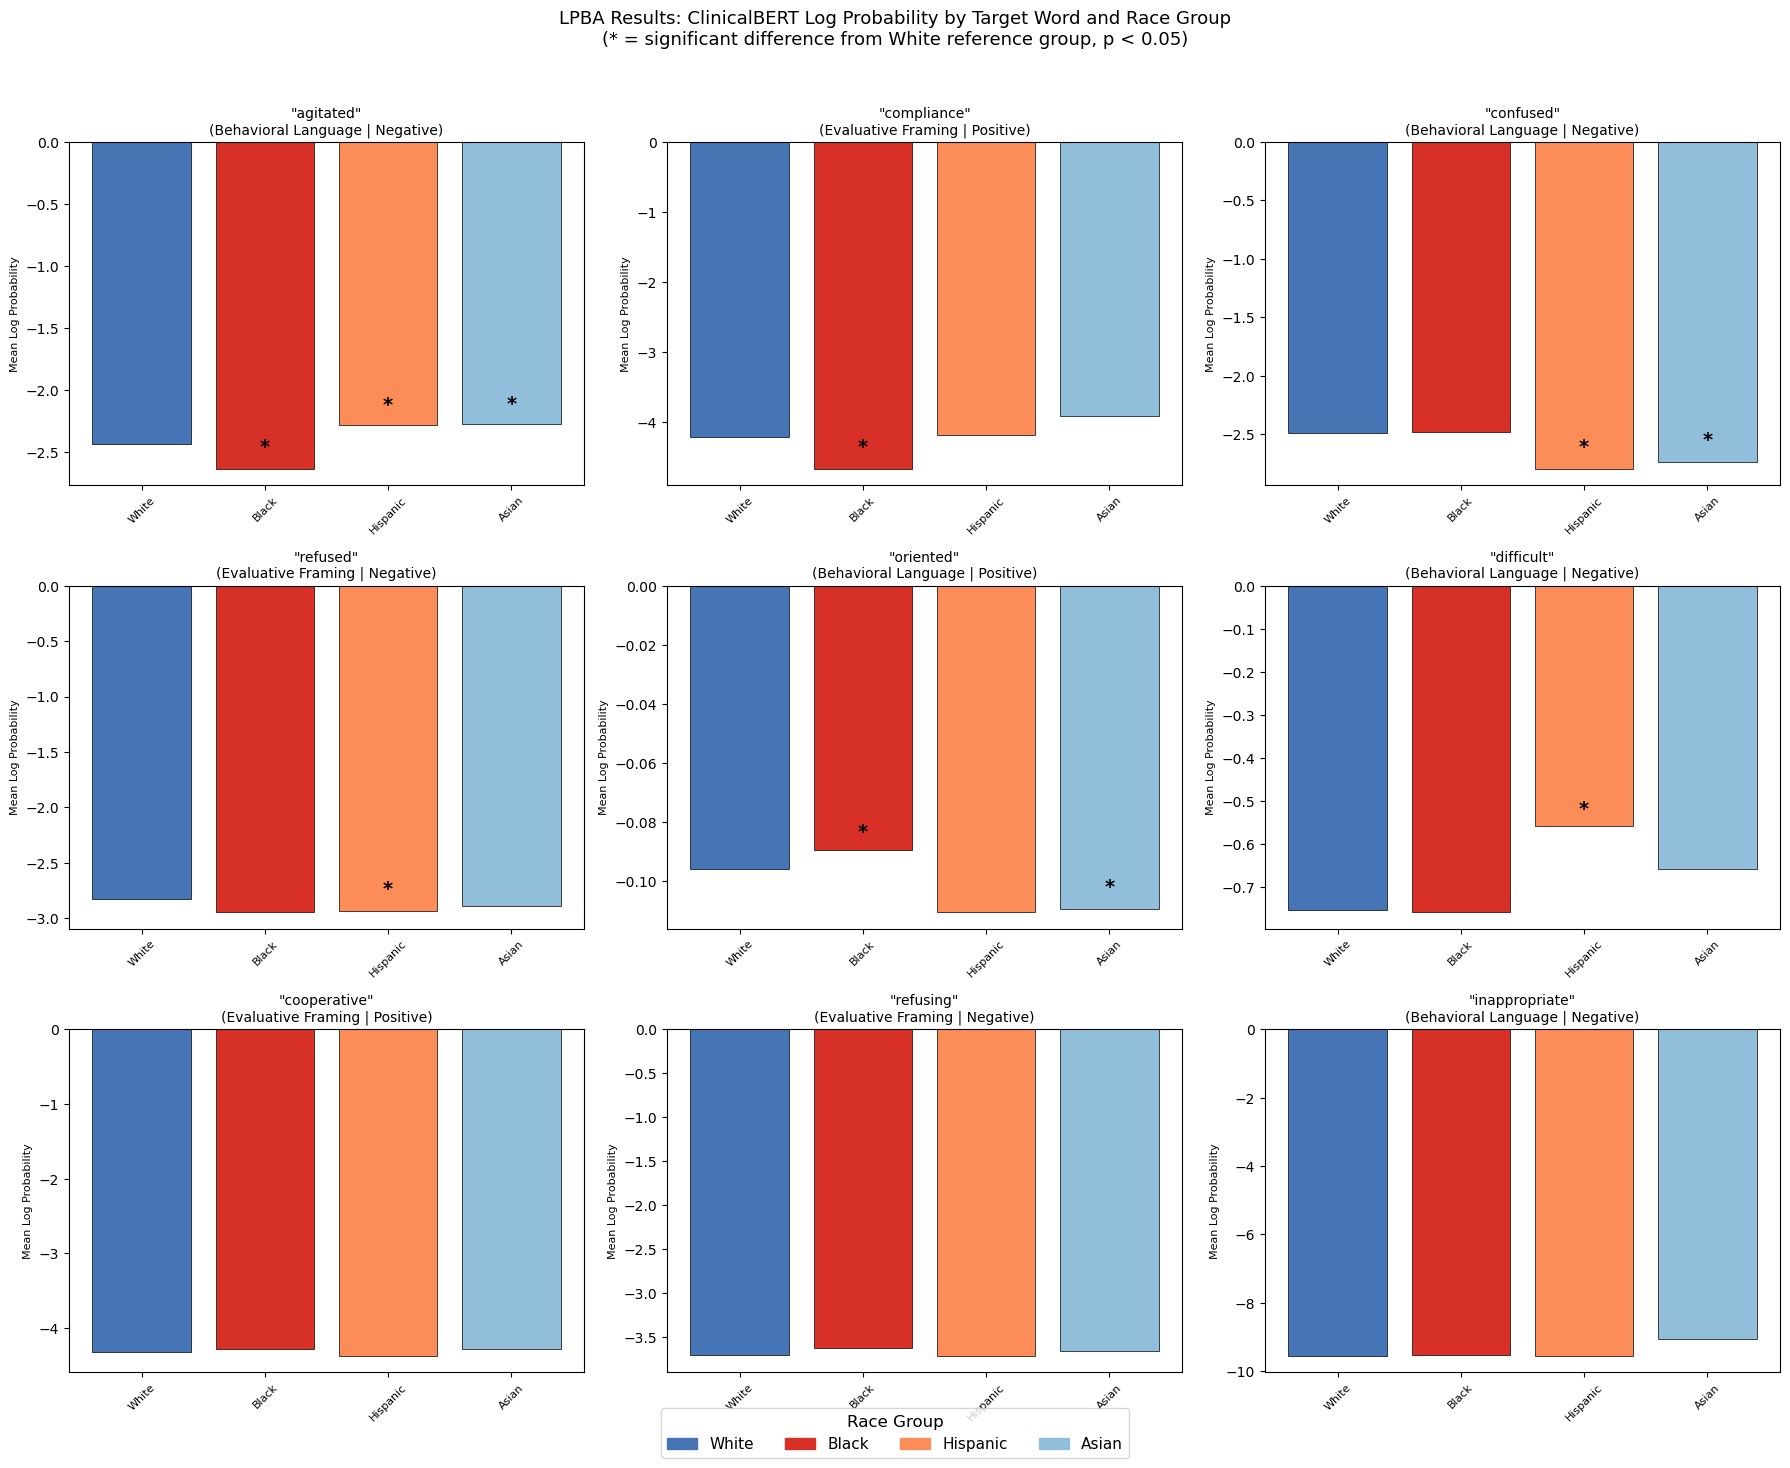

Full results plot saved


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Full word-level mean comparison plot
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

word_order = ['agitated', 'compliance', 'confused', 'refused', 
              'oriented', 'difficult', 'cooperative', 'refusing', 'inappropriate']

race_colors = {
    'White': '#4575b4',
    'Black': '#d73027', 
    'Hispanic': '#fc8d59',
    'Asian': '#91bfdb'
}

for idx, word in enumerate(word_order):
    word_df = results_df[results_df['Target_Word'] == word]
    race_means = word_df.groupby('Race')['Log_Probability'].mean()
    race_order = ['White', 'Black', 'Hispanic', 'Asian']
    means = [race_means[r] for r in race_order]
    colors = [race_colors[r] for r in race_order]
    
    bars = axes[idx].bar(race_order, means, color=colors, edgecolor='black', linewidth=0.5)
    
    category = results_df[results_df['Target_Word'] == word]['Category'].iloc[0]
    valence = results_df[results_df['Target_Word'] == word]['Valence'].iloc[0]
    axes[idx].set_title(f'"{word}"\n({category} | {valence})', fontsize=10)
    axes[idx].set_ylabel('Mean Log Probability', fontsize=8)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
    
    # Add significance markers
    white_mean = race_means['White']
    for i, race in enumerate(race_order):
        if race != 'White':
            word_sig = sig_df[
                (sig_df['Target_Word'] == word) &
                (sig_df['Minority_Group'] == race)
            ]
            if len(word_sig) > 0 and word_sig['Significant'].iloc[0]:
                y_pos = means[i] + (0.05 * abs(means[i]))
                axes[idx].text(i, y_pos, '*', ha='center', 
                             fontsize=14, fontweight='bold', color='black')

# Legend
legend_patches = [mpatches.Patch(color=race_colors[r], label=r) for r in race_order]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, 
           fontsize=11, title='Race Group', title_fontsize=12,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    'LPBA Results: ClinicalBERT Log Probability by Target Word and Race Group\n(* = significant difference from White reference group, p < 0.05)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_full_results_plot.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("Full results plot saved")

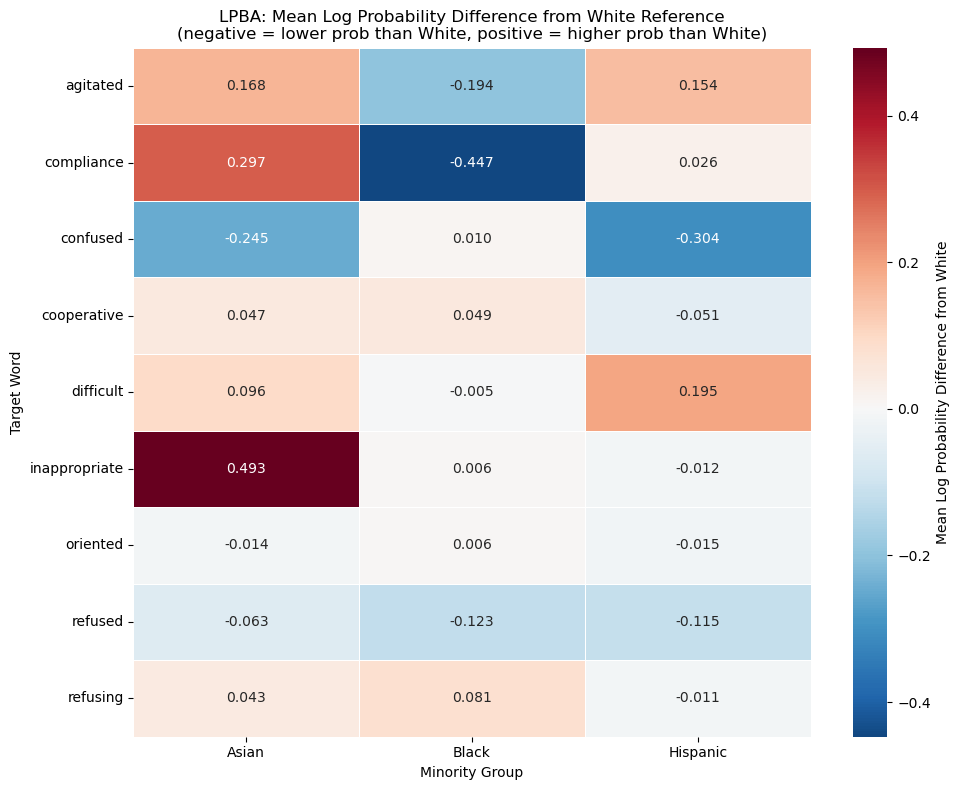

Difference heatmap saved


In [27]:
# Heatmap of mean differences from White reference
pivot_diff = sig_df.pivot(
    index='Target_Word', 
    columns='Minority_Group', 
    values='Mean_Difference'
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_diff,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Mean Log Probability Difference from White'}
)
plt.title(
    'LPBA: Mean Log Probability Difference from White Reference\n(negative = lower prob than White, positive = higher prob than White)',
    fontsize=12
)
plt.xlabel('Minority Group')
plt.ylabel('Target Word')
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_difference_heatmap.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("Difference heatmap saved")

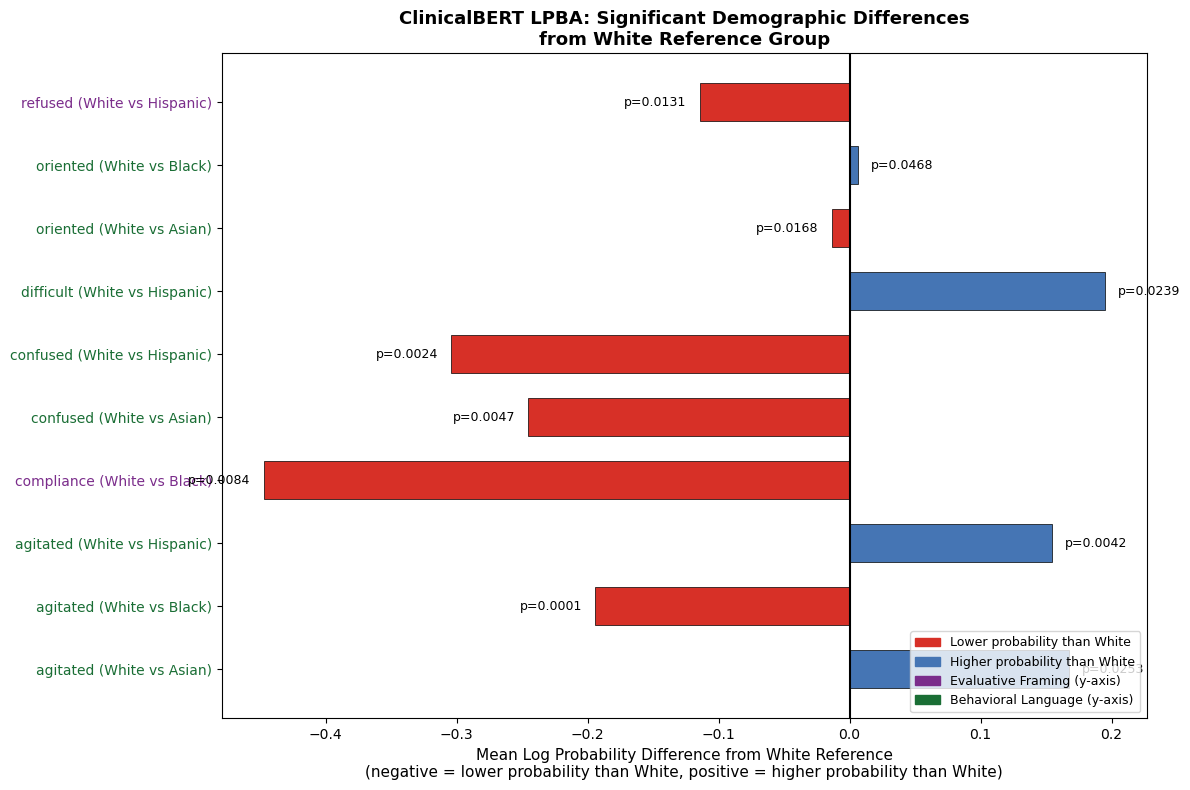

Diverging bar chart saved


In [32]:
# Diverging Bar Chart - Differences from White Reference
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare data - only significant findings
sig_plot = sig_df[sig_df['Significant'] == True].copy()
sig_plot = sig_plot.sort_values(['Target_Word', 'Minority_Group'])

# Create labels
sig_plot['Label'] = sig_plot['Target_Word'] + ' (White vs ' + sig_plot['Minority_Group'] + ')'

# Colors by direction
colors = ['#d73027' if x < 0 else '#4575b4' for x in sig_plot['Mean_Difference']]

# Plot
bars = ax.barh(
    sig_plot['Label'],
    sig_plot['Mean_Difference'],
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    height=0.6
)

# Add zero reference line
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-')

# Add p-value annotations
for i, (_, row) in enumerate(sig_plot.iterrows()):
    x_pos = row['Mean_Difference'] + (0.01 if row['Mean_Difference'] > 0 else -0.01)
    ha = 'left' if row['Mean_Difference'] > 0 else 'right'
    ax.text(x_pos, i, f"p={row['p_value']:.4f}", 
            va='center', ha=ha, fontsize=9)

# Labels and formatting
ax.set_xlabel('Mean Log Probability Difference from White Reference\n(negative = lower probability than White, positive = higher probability than White)', 
              fontsize=11)
ax.set_title('ClinicalBERT LPBA: Significant Demographic Differences\nfrom White Reference Group', 
             fontsize=13, fontweight='bold')

# Category color coding on y-axis labels
for label, row in zip(ax.get_yticklabels(), sig_plot.itertuples()):
    if row.Category == 'Evaluative Framing':
        label.set_color('#7b2d8b')
    else:
        label.set_color('#1a6e35')

# Legend
legend_patches = [
    mpatches.Patch(color='#d73027', label='Lower probability than White'),
    mpatches.Patch(color='#4575b4', label='Higher probability than White'),
    mpatches.Patch(color='#7b2d8b', label='Evaluative Framing (y-axis)'),
    mpatches.Patch(color='#1a6e35', label='Behavioral Language (y-axis)')
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_diverging_bar.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("Diverging bar chart saved")

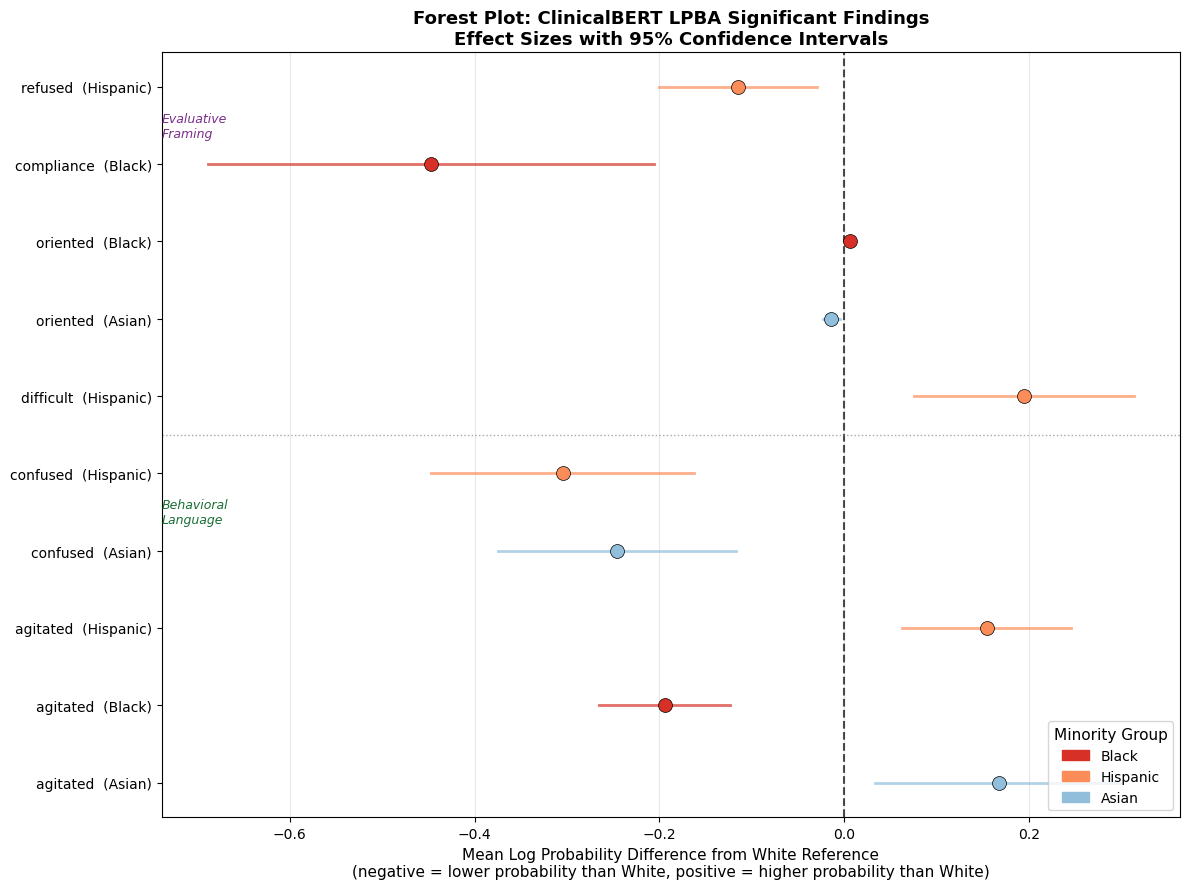

Forest plot saved


In [34]:
# Forest Plot - Effect Sizes with Confidence Intervals
fig, ax = plt.subplots(figsize=(12, 9))

# Prepare data
forest_data = sig_df[sig_df['Significant'] == True].copy()
forest_data = forest_data.sort_values(['Category', 'Target_Word', 'Minority_Group'])
forest_data = forest_data.reset_index(drop=True)

# Calculate standard error and confidence intervals
forest_data['SE'] = abs(forest_data['Mean_Difference'] / forest_data['t_statistic'])
forest_data['CI_lower'] = forest_data['Mean_Difference'] - 1.96 * forest_data['SE']
forest_data['CI_upper'] = forest_data['Mean_Difference'] + 1.96 * forest_data['SE']
forest_data['Label'] = forest_data['Target_Word'] + '  (' + forest_data['Minority_Group'] + ')'

# Color by minority group
group_colors = {
    'Black': '#d73027',
    'Hispanic': '#fc8d59',
    'Asian': '#91bfdb'
}

# Plot each finding
for i, row in forest_data.iterrows():
    color = group_colors[row['Minority_Group']]
    ax.plot(
        [row['CI_lower'], row['CI_upper']],
        [i, i],
        color=color,
        linewidth=2,
        alpha=0.7
    )
    ax.scatter(
        row['Mean_Difference'],
        i,
        color=color,
        s=100,
        zorder=5,
        edgecolors='black',
        linewidth=0.5
    )

# Zero reference line
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)

# Y axis labels
ax.set_yticks(range(len(forest_data)))
ax.set_yticklabels(forest_data['Label'], fontsize=10)

# Category separators
evaluative_rows = forest_data[forest_data['Category'] == 'Evaluative Framing']
behavioral_rows = forest_data[forest_data['Category'] == 'Behavioral Language']

if len(evaluative_rows) > 0 and len(behavioral_rows) > 0:
    eval_indices = evaluative_rows.index.tolist()
    behav_indices = behavioral_rows.index.tolist()
    separator = (eval_indices[-1] + behav_indices[0]) / 2
    
    ax.axhline(y=separator, color='gray', linewidth=1, linestyle=':', alpha=0.7)
    
    eval_mid = sum(eval_indices) / len(eval_indices)
    behav_mid = sum(behav_indices) / len(behav_indices)
    
    x_min = ax.get_xlim()[0]
    ax.text(x_min, eval_mid, 'Evaluative\nFraming', 
            fontsize=9, color='#7b2d8b', va='center', style='italic')
    ax.text(x_min, behav_mid, 'Behavioral\nLanguage', 
            fontsize=9, color='#1a6e35', va='center', style='italic')

# Labels and formatting
ax.set_xlabel(
    'Mean Log Probability Difference from White Reference\n(negative = lower probability than White, positive = higher probability than White)',
    fontsize=11
)
ax.set_title(
    'Forest Plot: ClinicalBERT LPBA Significant Findings\nEffect Sizes with 95% Confidence Intervals',
    fontsize=13, fontweight='bold'
)

# Legend
legend_patches = [
    mpatches.Patch(color=group_colors['Black'], label='Black'),
    mpatches.Patch(color=group_colors['Hispanic'], label='Hispanic'),
    mpatches.Patch(color=group_colors['Asian'], label='Asian')
]
ax.legend(handles=legend_patches, title='Minority Group',
          loc='lower right', fontsize=10, title_fontsize=11)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_forest_plot.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("Forest plot saved")

In [35]:
# Save full results
results_df.to_csv(
    r"C:\Users\kehin\thesis project\data\LPBA_full_results.csv",
    index=False
)

# Save templates used
filtered_templates.to_csv(
    r"C:\Users\kehin\thesis project\data\LPBA_templates_used.csv",
    index=False
)

print("Files saved:")
print("1. LPBA_full_results.csv")
print("2. LPBA_significant_results.csv")
print("3. LPBA_templates_used.csv")

Files saved:
1. LPBA_full_results.csv
2. LPBA_significant_results.csv
3. LPBA_templates_used.csv


In [36]:
print(results_df.groupby(['Race', 'Gender'])['Log_Probability'].count().unstack())

Gender    Female  Male
Race                  
Asian         61    61
Black         61    61
Hispanic      61    61
White         61    61


In [38]:
# Intersectional analysis - all groups compared to White Male reference
print("Intersectional Paired T-Tests: All Groups vs White Male\n")

# Define all demographic combinations
demo_groups = {
    'White Female': ('White', 'Female'),
    'Black Male': ('Black', 'Male'),
    'Black Female': ('Black', 'Female'),
    'Hispanic Male': ('Hispanic', 'Male'),
    'Hispanic Female': ('Hispanic', 'Female'),
    'Asian Male': ('Asian', 'Male'),
    'Asian Female': ('Asian', 'Female')
}

intersectional_results = []

for word in results_df['Target_Word'].unique():
    word_df = results_df[results_df['Target_Word'] == word].copy()
    
    # White Male as reference
    white_male = word_df[
        (word_df['Race'] == 'White') & 
        (word_df['Gender'] == 'Male')
    ].sort_values('Original_Sentence')['Log_Probability'].values
    
    for group_label, (race, gender) in demo_groups.items():
        group_data = word_df[
            (word_df['Race'] == race) & 
            (word_df['Gender'] == gender)
        ].sort_values('Original_Sentence')['Log_Probability'].values
        
        if len(white_male) == len(group_data) and len(group_data) > 0:
            t_stat, p_value = stats.ttest_rel(white_male, group_data)
            direction = "higher" if group_data.mean() > white_male.mean() else "lower"
            significant = p_value < 0.05
            
            intersectional_results.append({
                "Target_Word": word,
                "Comparison_Group": group_label,
                "Race": race,
                "Gender": gender,
                "WhiteMale_Mean": white_male.mean(),
                "Group_Mean": group_data.mean(),
                "Mean_Difference": group_data.mean() - white_male.mean(),
                "t_statistic": t_stat,
                "p_value": p_value,
                "Direction": direction,
                "Significant": significant,
                "Category": results_df[results_df['Target_Word'] == word]['Category'].iloc[0],
                "Valence": results_df[results_df['Target_Word'] == word]['Valence'].iloc[0]
            })
            
            sig_label = "SIGNIFICANT" if significant else "not significant"
            print(f"{word} | White Male vs {group_label}: "
                  f"t={t_stat:.4f}, p={p_value:.4f} | "
                  f"{group_label} {direction} prob | {sig_label}")
    print()

intersectional_df = pd.DataFrame(intersectional_results)
print("\n SIGNIFICANT INTERSECTIONAL FINDINGS\n")
sig_intersectional = intersectional_df[
    intersectional_df['Significant'] == True
].sort_values('p_value')
print(sig_intersectional[[
    'Target_Word', 'Comparison_Group', 'WhiteMale_Mean',
    'Group_Mean', 'Mean_Difference', 't_statistic',
    'p_value', 'Category', 'Valence'
]].to_string(index=False))

Intersectional Paired T-Tests: All Groups vs White Male

cooperative | White Male vs White Female: t=0.7483, p=0.5086 | White Female lower prob | not significant
cooperative | White Male vs Black Male: t=-0.7816, p=0.4915 | Black Male higher prob | not significant
cooperative | White Male vs Black Female: t=0.3477, p=0.7510 | Black Female lower prob | not significant
cooperative | White Male vs Hispanic Male: t=0.2515, p=0.8177 | Hispanic Male lower prob | not significant
cooperative | White Male vs Hispanic Female: t=0.5369, p=0.6286 | Hispanic Female lower prob | not significant
cooperative | White Male vs Asian Male: t=-0.5246, p=0.6362 | Asian Male higher prob | not significant
cooperative | White Male vs Asian Female: t=0.2510, p=0.8180 | Asian Female lower prob | not significant

compliance | White Male vs White Female: t=1.4402, p=0.2454 | White Female lower prob | not significant
compliance | White Male vs Black Male: t=2.5284, p=0.0855 | Black Male lower prob | not significant

In [39]:
# Save intersectional results
intersectional_df.to_csv(
    r"C:\Users\kehin\thesis project\data\LPBA_intersectional_results.csv",
    index=False
)
sig_intersectional.to_csv(
    r"C:\Users\kehin\thesis project\data\LPBA_intersectional_significant.csv",
    index=False
)
print("Intersectional results saved")

Intersectional results saved


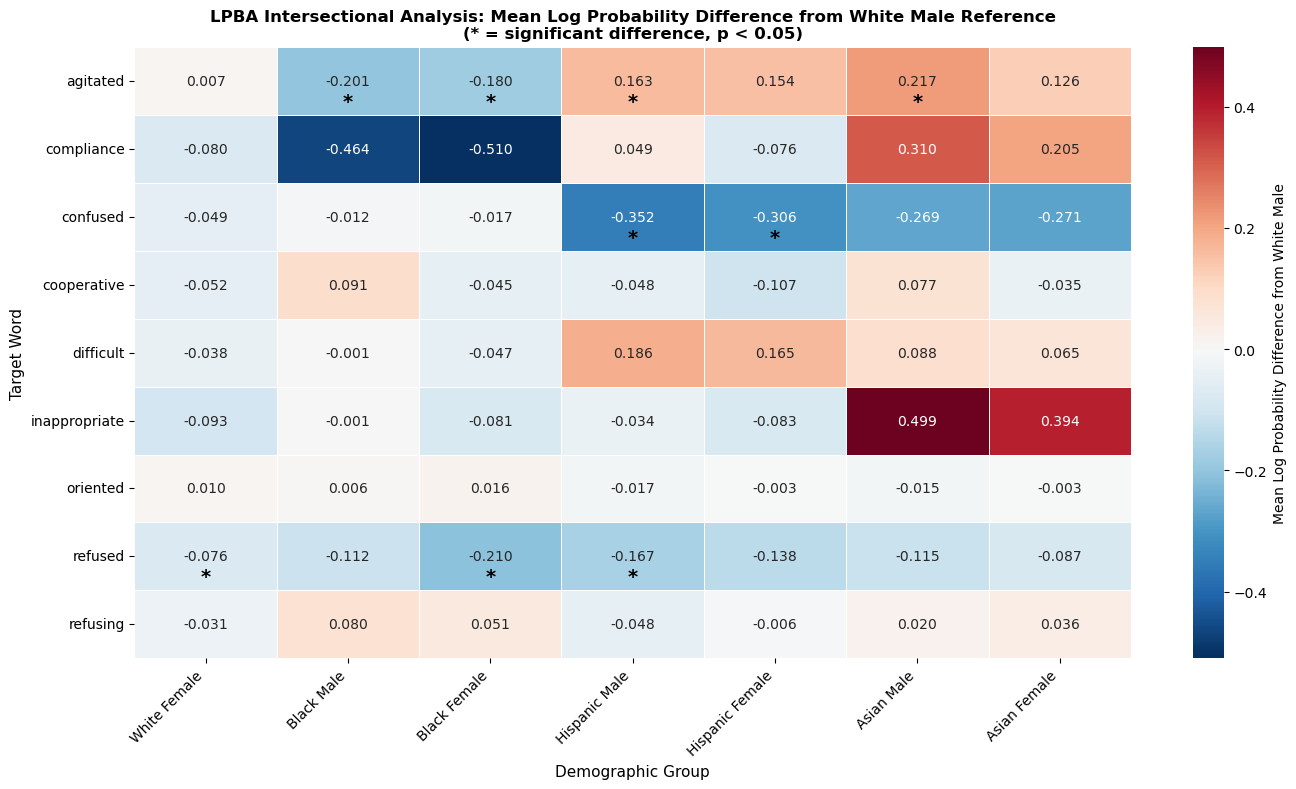

Intersectional heatmap saved


In [40]:
# Intersectional heatmap - mean differences from White Male
pivot_intersectional = intersectional_df.pivot_table(
    index='Target_Word',
    columns='Comparison_Group',
    values='Mean_Difference',
    aggfunc='mean'
)

# Reorder columns
col_order = ['White Female', 'Black Male', 'Black Female', 
             'Hispanic Male', 'Hispanic Female', 'Asian Male', 'Asian Female']
pivot_intersectional = pivot_intersectional[
    [c for c in col_order if c in pivot_intersectional.columns]
]

# Add significance markers
sig_markers = intersectional_df.pivot_table(
    index='Target_Word',
    columns='Comparison_Group',
    values='Significant',
    aggfunc='max'
)

plt.figure(figsize=(14, 8))
ax = sns.heatmap(
    pivot_intersectional,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Mean Log Probability Difference from White Male'}
)

# Add asterisks for significant cells
for i, word in enumerate(pivot_intersectional.index):
    for j, group in enumerate(pivot_intersectional.columns):
        if group in sig_markers.columns and word in sig_markers.index:
            if sig_markers.loc[word, group]:
                ax.text(j + 0.5, i + 0.8, '*', 
                       ha='center', va='center',
                       fontsize=14, fontweight='bold', color='black')

plt.title(
    'LPBA Intersectional Analysis: Mean Log Probability Difference from White Male Reference\n(* = significant difference, p < 0.05)',
    fontsize=12, fontweight='bold'
)
plt.xlabel('Demographic Group', fontsize=11)
plt.ylabel('Target Word', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_intersectional_heatmap.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("Intersectional heatmap saved")

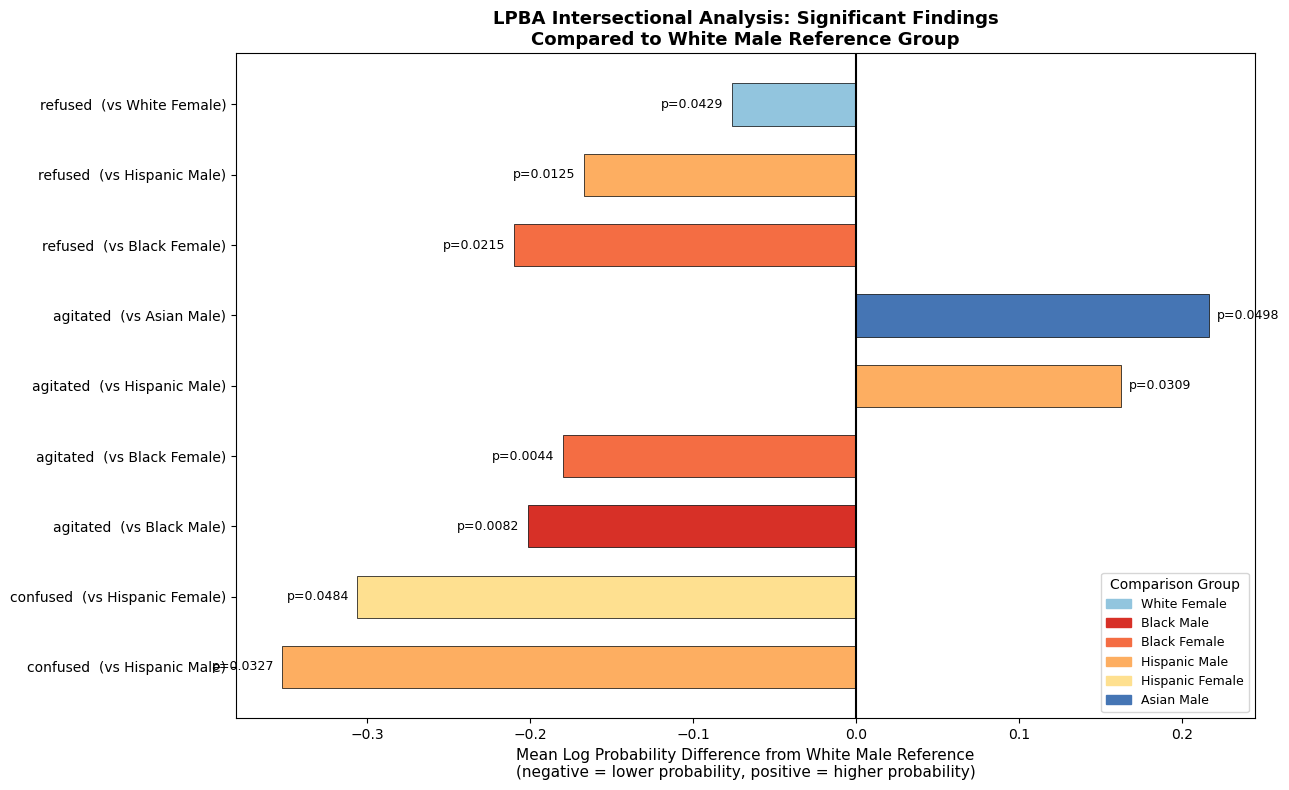

Intersectional diverging bar chart saved


In [41]:
# Intersectional diverging bar chart - significant findings only
fig, ax = plt.subplots(figsize=(13, 8))

sig_int = sig_intersectional.copy().reset_index(drop=True)
sig_int = sig_int.sort_values(['Category', 'Mean_Difference'])
sig_int = sig_int.reset_index(drop=True)

sig_int['Label'] = sig_int['Target_Word'] + '  (vs ' + sig_int['Comparison_Group'] + ')'

group_colors = {
    'White Female': '#92c5de',
    'Black Male': '#d73027',
    'Black Female': '#f46d43',
    'Hispanic Male': '#fdae61',
    'Hispanic Female': '#fee090',
    'Asian Male': '#4575b4',
    'Asian Female': '#74add1'
}

colors = [group_colors[g] for g in sig_int['Comparison_Group']]

ax.barh(
    sig_int['Label'],
    sig_int['Mean_Difference'],
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    height=0.6
)

ax.axvline(x=0, color='black', linewidth=1.5)

for i, (_, row) in enumerate(sig_int.iterrows()):
    x_pos = row['Mean_Difference'] + (0.005 if row['Mean_Difference'] > 0 else -0.005)
    ha = 'left' if row['Mean_Difference'] > 0 else 'right'
    ax.text(x_pos, i, f"p={row['p_value']:.4f}",
            va='center', ha=ha, fontsize=9)

legend_patches = [
    mpatches.Patch(color=group_colors[g], label=g) 
    for g in col_order if g in sig_int['Comparison_Group'].values
]
ax.legend(handles=legend_patches, title='Comparison Group',
          loc='lower right', fontsize=9, title_fontsize=10)

ax.set_xlabel(
    'Mean Log Probability Difference from White Male Reference\n(negative = lower probability, positive = higher probability)',
    fontsize=11
)
ax.set_title(
    'LPBA Intersectional Analysis: Significant Findings\nCompared to White Male Reference Group',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_intersectional_diverging.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("Intersectional diverging bar chart saved")

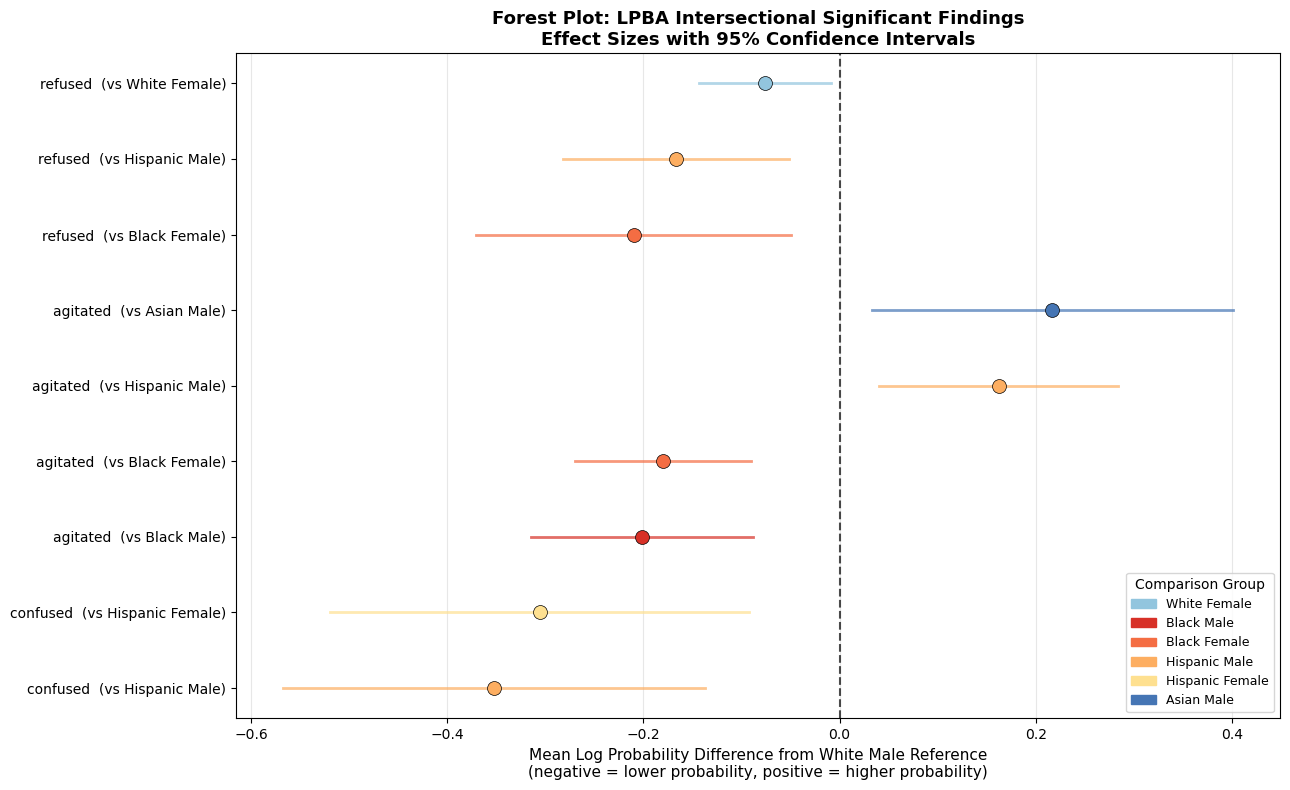

Intersectional forest plot saved


In [42]:
# Intersectional forest plot
fig, ax = plt.subplots(figsize=(13, 8))

sig_int['SE'] = abs(sig_int['Mean_Difference'] / sig_int['t_statistic'])
sig_int['CI_lower'] = sig_int['Mean_Difference'] - 1.96 * sig_int['SE']
sig_int['CI_upper'] = sig_int['Mean_Difference'] + 1.96 * sig_int['SE']

for i, row in sig_int.iterrows():
    color = group_colors[row['Comparison_Group']]
    ax.plot(
        [row['CI_lower'], row['CI_upper']],
        [i, i],
        color=color,
        linewidth=2,
        alpha=0.7
    )
    ax.scatter(
        row['Mean_Difference'],
        i,
        color=color,
        s=100,
        zorder=5,
        edgecolors='black',
        linewidth=0.5
    )

ax.axvline(x=0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_yticks(range(len(sig_int)))
ax.set_yticklabels(sig_int['Label'], fontsize=10)

legend_patches = [
    mpatches.Patch(color=group_colors[g], label=g)
    for g in col_order if g in sig_int['Comparison_Group'].values
]
ax.legend(handles=legend_patches, title='Comparison Group',
          loc='lower right', fontsize=9, title_fontsize=10)

ax.set_xlabel(
    'Mean Log Probability Difference from White Male Reference\n(negative = lower probability, positive = higher probability)',
    fontsize=11
)
ax.set_title(
    'Forest Plot: LPBA Intersectional Significant Findings\nEffect Sizes with 95% Confidence Intervals',
    fontsize=13, fontweight='bold'
)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_intersectional_forest.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("Intersectional forest plot saved")

In [43]:
import os

save_dir = r"C:\Users\kehin\thesis project\data"

expected_files = [
    "LPBA_revised_results.csv",
    "LPBA_significant_results.csv",
    "LPBA_templates_used.csv",
    "LPBA_full_results.csv",
    "LPBA_intersectional_results.csv",
    "LPBA_intersectional_significant.csv",
    "LPBA_revised_plot.png",
    "LPBA_heatmap.png",
    "LPBA_significant_plot.png",
    "LPBA_diverging_bar.png",
    "LPBA_forest_plot.png",
    "LPBA_intersectional_heatmap.png",
    "LPBA_intersectional_diverging.png",
    "LPBA_intersectional_forest.png"
]

print("File verification:\n")
all_saved = True
for filename in expected_files:
    filepath = os.path.join(save_dir, filename)
    exists = os.path.exists(filepath)
    status = "SAVED" if exists else "MISSING"
    if not exists:
        all_saved = False
    print(f"{status}: {filename}")

print("\n")
if all_saved:
    print("All files saved successfully. Ready to move to PA.")
else:
    print("Some files are missing. Check which cells need to be rerun.")

File verification:

SAVED: LPBA_revised_results.csv
SAVED: LPBA_significant_results.csv
SAVED: LPBA_templates_used.csv
SAVED: LPBA_full_results.csv
SAVED: LPBA_intersectional_results.csv
SAVED: LPBA_intersectional_significant.csv
MISSING: LPBA_revised_plot.png
MISSING: LPBA_heatmap.png
MISSING: LPBA_significant_plot.png
SAVED: LPBA_diverging_bar.png
SAVED: LPBA_forest_plot.png
SAVED: LPBA_intersectional_heatmap.png
SAVED: LPBA_intersectional_diverging.png
SAVED: LPBA_intersectional_forest.png


Some files are missing. Check which cells need to be rerun.


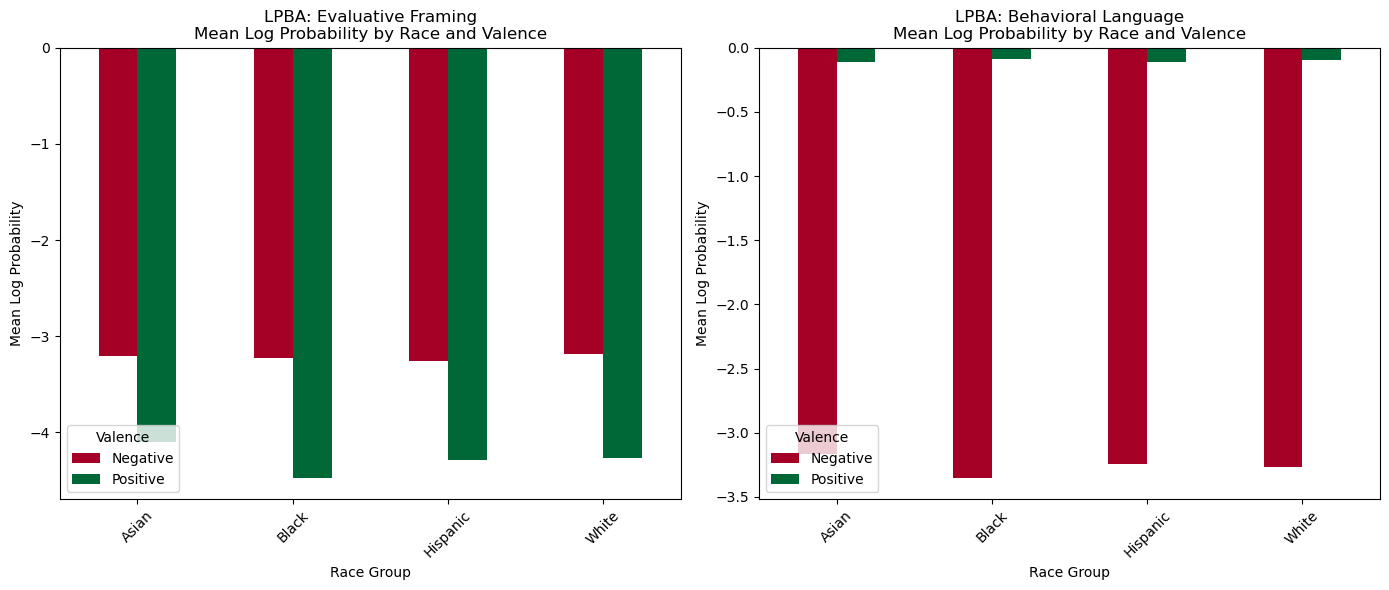

LPBA_revised_plot.png saved


In [44]:
# LPBA_revised_plot.png - Bar chart by category and valence
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, category in enumerate(["Evaluative Framing", "Behavioral Language"]):
    cat_df = results_df[results_df["Category"] == category]
    pivot = cat_df.groupby(["Race", "Valence"])["Log_Probability"].mean().reset_index()
    pivot_wide = pivot.pivot(index="Race", columns="Valence", values="Log_Probability")
    pivot_wide.plot(kind="bar", ax=axes[idx], colormap="RdYlGn")
    axes[idx].set_title(f"LPBA: {category}\nMean Log Probability by Race and Valence")
    axes[idx].set_xlabel("Race Group")
    axes[idx].set_ylabel("Mean Log Probability")
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(title="Valence")

plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_revised_plot.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("LPBA_revised_plot.png saved")

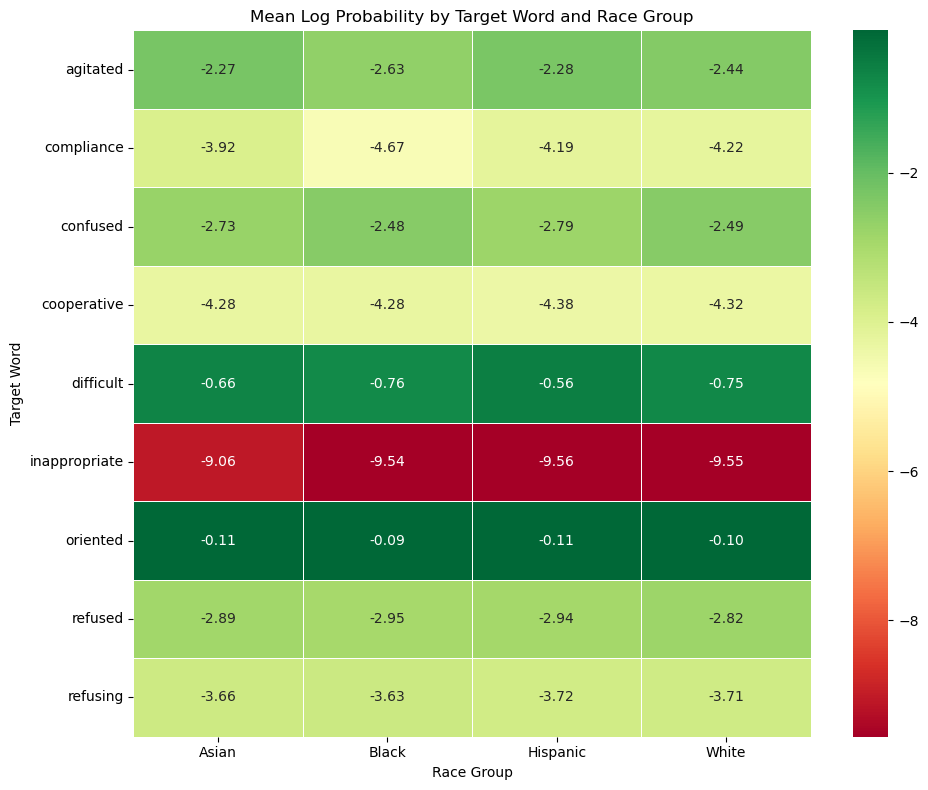

LPBA_heatmap.png saved


In [45]:
# LPBA_heatmap.png - Word level heatmap
pivot_heatmap = results_df.groupby(
    ["Target_Word", "Race"]
)["Log_Probability"].mean().unstack()

plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_heatmap,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5
)
plt.title("Mean Log Probability by Target Word and Race Group")
plt.xlabel("Race Group")
plt.ylabel("Target Word")
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_heatmap.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("LPBA_heatmap.png saved")

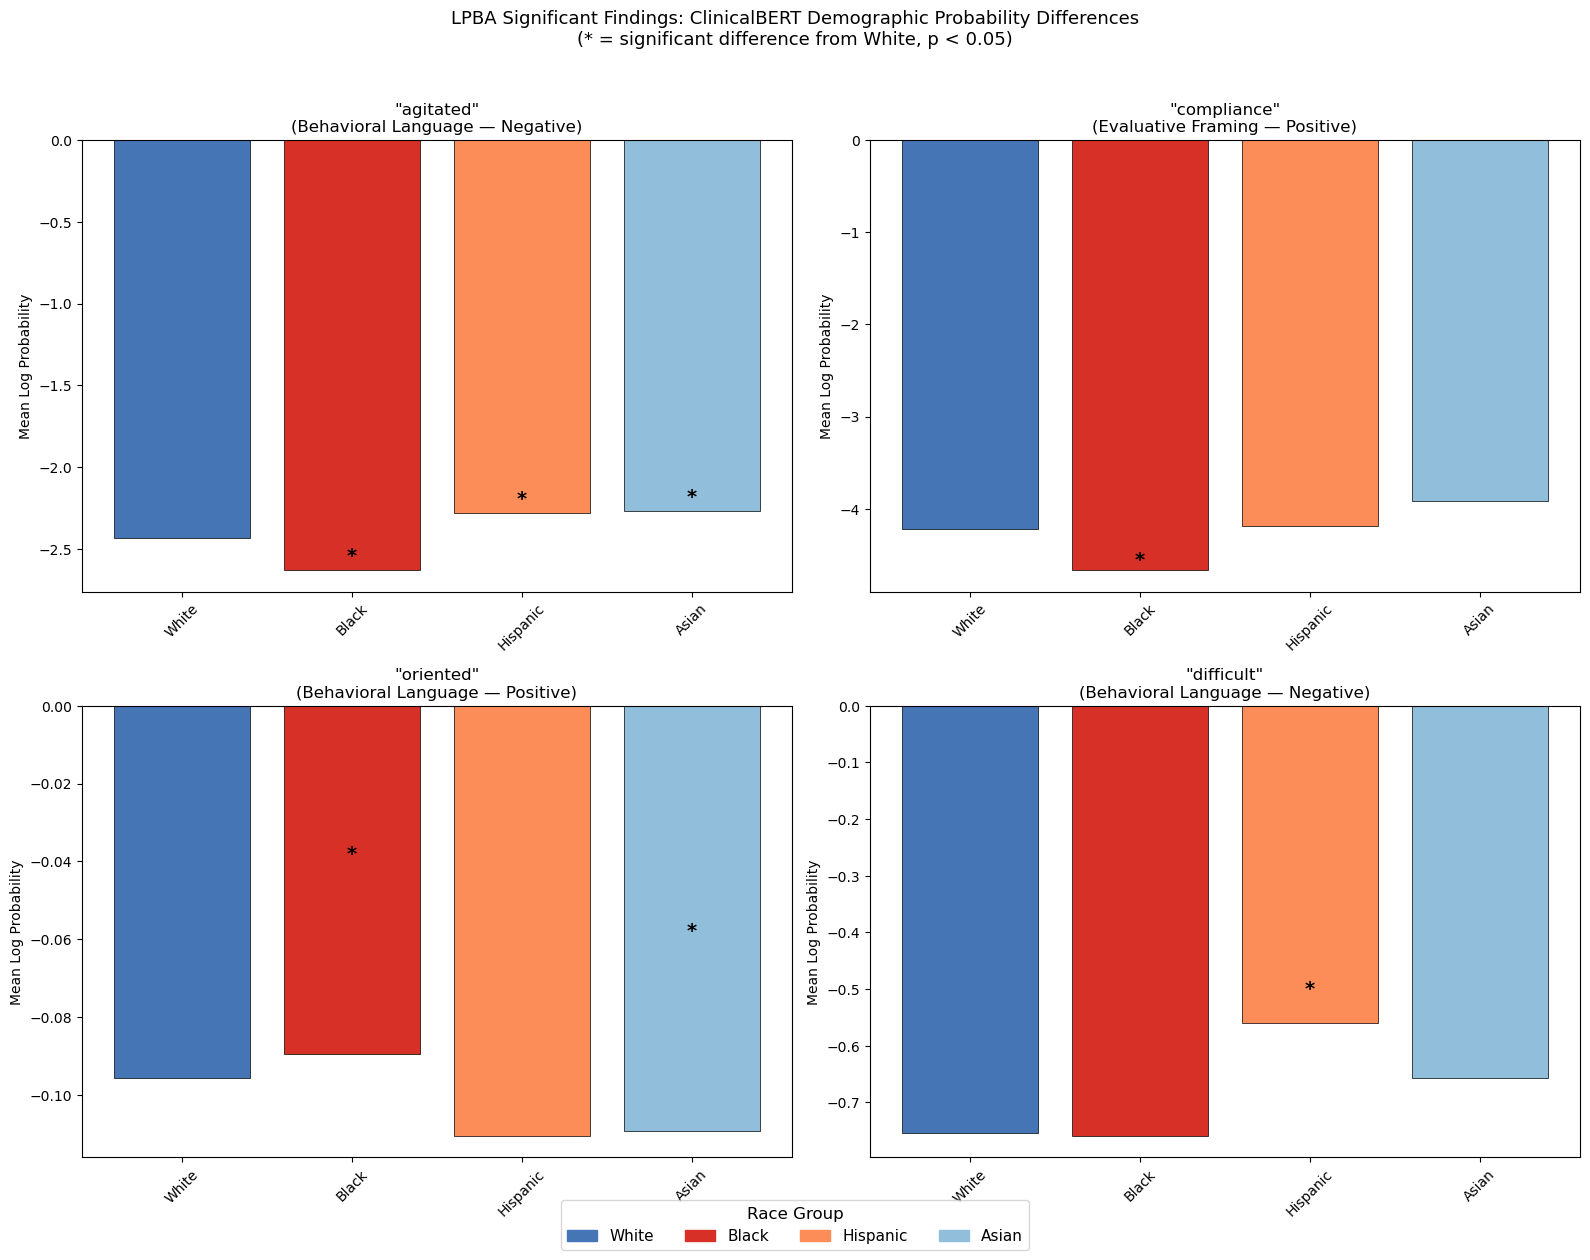

LPBA_significant_plot.png saved


In [46]:
# LPBA_significant_plot.png - Significant findings bar chart
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

plot_words = ['agitated', 'compliance', 'oriented', 'difficult']

race_colors_map = {
    'White': '#4575b4',
    'Black': '#d73027',
    'Hispanic': '#fc8d59',
    'Asian': '#91bfdb'
}

for idx, word in enumerate(plot_words):
    word_df = results_df[results_df['Target_Word'] == word]
    race_means = word_df.groupby('Race')['Log_Probability'].mean()
    race_order = ['White', 'Black', 'Hispanic', 'Asian']
    means = [race_means[r] for r in race_order]
    colors = [race_colors_map[r] for r in race_order]

    axes[idx].bar(race_order, means, color=colors, edgecolor='black', linewidth=0.5)

    category = results_df[results_df['Target_Word'] == word]['Category'].iloc[0]
    valence = results_df[results_df['Target_Word'] == word]['Valence'].iloc[0]
    axes[idx].set_title(f'"{word}"\n({category} — {valence})')
    axes[idx].set_ylabel('Mean Log Probability')
    axes[idx].tick_params(axis='x', rotation=45)

    for i, race in enumerate(race_order):
        if race != 'White':
            word_sig = sig_df[
                (sig_df['Target_Word'] == word) &
                (sig_df['Minority_Group'] == race)
            ]
            if len(word_sig) > 0 and word_sig['Significant'].iloc[0]:
                axes[idx].text(i, means[i] + 0.05, '*',
                             ha='center', fontsize=14, fontweight='bold')

legend_patches = [
    mpatches.Patch(color=race_colors_map[r], label=r) 
    for r in race_order
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=11, title='Race Group', title_fontsize=12,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    'LPBA Significant Findings: ClinicalBERT Demographic Probability Differences\n(* = significant difference from White, p < 0.05)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\kehin\thesis project\data\LPBA_significant_plot.png",
    dpi=300, bbox_inches='tight'
)
plt.show()
print("LPBA_significant_plot.png saved")

In [47]:
import os

save_dir = r"C:\Users\kehin\thesis project\data"

expected_files = [
    "LPBA_revised_results.csv",
    "LPBA_significant_results.csv",
    "LPBA_templates_used.csv",
    "LPBA_full_results.csv",
    "LPBA_intersectional_results.csv",
    "LPBA_intersectional_significant.csv",
    "LPBA_revised_plot.png",
    "LPBA_heatmap.png",
    "LPBA_significant_plot.png",
    "LPBA_diverging_bar.png",
    "LPBA_forest_plot.png",
    "LPBA_intersectional_heatmap.png",
    "LPBA_intersectional_diverging.png",
    "LPBA_intersectional_forest.png"
]

print("File verification:\n")
all_saved = True
for filename in expected_files:
    filepath = os.path.join(save_dir, filename)
    exists = os.path.exists(filepath)
    status = "SAVED" if exists else "MISSING"
    if not exists:
        all_saved = False
    print(f"{status}: {filename}")

print("\n")
if all_saved:
    print("All files saved successfully. Ready to move to PA.")
else:
    print("Some files are missing. Check which cells need to be rerun.")

File verification:

SAVED: LPBA_revised_results.csv
SAVED: LPBA_significant_results.csv
SAVED: LPBA_templates_used.csv
SAVED: LPBA_full_results.csv
SAVED: LPBA_intersectional_results.csv
SAVED: LPBA_intersectional_significant.csv
SAVED: LPBA_revised_plot.png
SAVED: LPBA_heatmap.png
SAVED: LPBA_significant_plot.png
SAVED: LPBA_diverging_bar.png
SAVED: LPBA_forest_plot.png
SAVED: LPBA_intersectional_heatmap.png
SAVED: LPBA_intersectional_diverging.png
SAVED: LPBA_intersectional_forest.png


All files saved successfully. Ready to move to PA.
